In [1]:
# ================================================================
# TASK 2 - DEEP LEARNING PROJECT
# CODTECH IT Solutions - Data Science Internship
# Description : Sentiment Analysis on Movie Reviews using LSTM
# Dataset     : IMDB Movie Reviews (built into Keras)
# Framework   : TensorFlow / Keras
# ================================================================

# --- All imports at the top (industry best practice) ---
import re
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print('TensorFlow version:', tf.__version__)
print('✅ All libraries imported successfully!')

TensorFlow version: 2.21.0
✅ All libraries imported successfully!


In [2]:
# ================================================================
# STEP 1: LOAD DATA
# IMDB dataset is built into Keras - no downloading needed!
# num_words=10000 means we only keep the 10,000 most common words
# This reduces noise from very rare words
# ================================================================

NUM_WORDS = 10000   # Vocabulary size - top 10k most common words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=NUM_WORDS)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')
print(f'\nLabel meaning    : 0 = Negative, 1 = Positive')
print(f'Sample label     : {y_train[0]}')
print(f'Sample review (as numbers): {X_train[0][:10]}...')

Training samples : 25000
Testing samples  : 25000

Label meaning    : 0 = Negative, 1 = Positive
Sample label     : 1
Sample review (as numbers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]...


In [3]:
# ================================================================
# STEP 2: EXPLORE
# Reviews are stored as sequences of integers.
# Each integer maps to a specific word in the vocabulary.
# We decode one review to verify data loaded correctly.
# ================================================================

# Get the word index dictionary (word → number mapping)
word_index = imdb.get_word_index()

# Reverse it so we can decode numbers back to words
reverse_index = {value: key for key, value in word_index.items()}

# Decode a review back to readable text
def decode_review(encoded):
    return ' '.join([reverse_index.get(i - 3, '?') for i in encoded])

print('--- First Review (decoded) ---')
print(decode_review(X_train[0]))
print(f"\nLabel: {'Positive 😊' if y_train[0] == 1 else 'Negative 😞'}")

# Check review lengths to decide padding size
lengths = [len(review) for review in X_train]
print(f'\nAverage review length : {int(np.mean(lengths))} words')
print(f'Max review length     : {max(lengths)} words')
print(f'Min review length     : {min(lengths)} words')

--- First Review (decoded) ---
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for wh

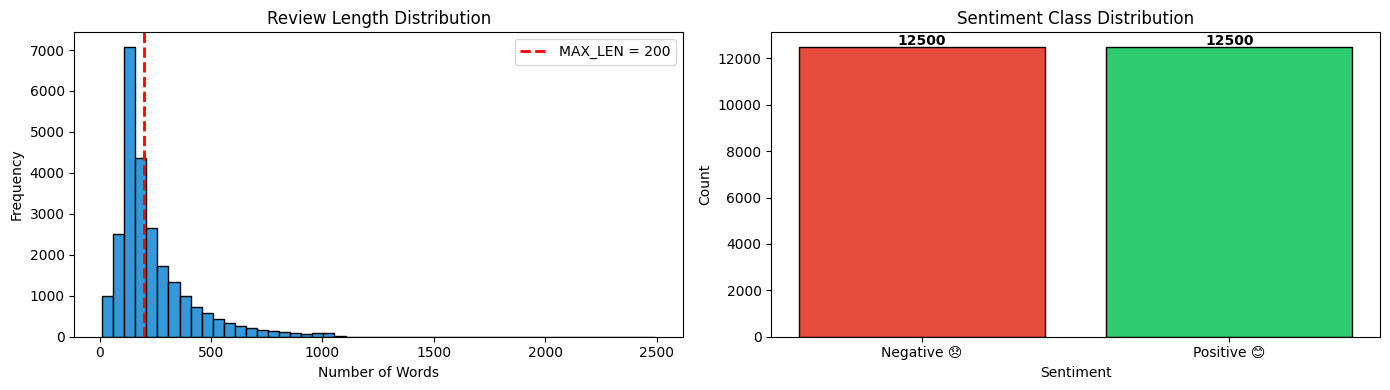

✅ EDA plots saved as eda_plots.png


In [4]:
# ================================================================
# STEP 2b: VISUALIZE - Review Length Distribution
# Since we calculated lengths above and use them to set MAX_LEN,
# it makes sense to visualize the distribution.
# This confirms that MAX_LEN=200 covers most reviews well.
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Review length histogram
# Shows us how long most reviews are - justifies MAX_LEN=200
axes[0].hist(lengths, bins=50, color='#3498db', edgecolor='black')
axes[0].axvline(x=200, color='red', linestyle='--',
                linewidth=2, label='MAX_LEN = 200')
axes[0].set_title('Review Length Distribution')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot 2: Sentiment class balance
# Checks if dataset is balanced (important for fair training)
unique, counts = np.unique(y_train, return_counts=True)
axes[1].bar(['Negative 😞', 'Positive 😊'], counts,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Sentiment Class Distribution')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
for i, count in enumerate(counts):
    axes[1].text(i, count + 100, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved as eda_plots.png')

In [5]:
# ================================================================
# STEP 3: PREPROCESSING - Padding
# Neural networks need ALL inputs to be the SAME length.
# Reviews shorter than 200 words → pad with zeros at the start
# Reviews longer than 200 words → cut from the start
# 200 is chosen because it covers the average review length
# ================================================================

MAX_LEN = 200   # Maximum length of each review

X_train_pad = pad_sequences(X_train, maxlen=MAX_LEN, padding='pre', truncating='pre')
X_test_pad  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='pre', truncating='pre')

print(f'Shape before padding : variable length')
print(f'Shape after padding  : {X_train_pad.shape}')
print(f'\nFirst padded review (first 10 values):')
print(X_train_pad[0][:10])
print('(zeros mean padding was added here)')

Shape before padding : variable length
Shape after padding  : (25000, 200)

First padded review (first 10 values):
[  5  25 100  43 838 112  50 670   2   9]
(zeros mean padding was added here)


In [6]:
# ================================================================
# STEP 4: BUILD THE MODEL
# Each layer has a specific job:
#
# Embedding : Converts word numbers into 128-dimensional vectors
#             Words with similar meanings get similar vectors
#             e.g. 'good' and 'great' will be close together
#
# LSTM      : Reads the review word by word like a human
#             Remembers context - knows 'not good' is negative
#
# Dropout   : Randomly turns off 30% neurons during training
#             Prevents model from memorizing (overfitting)
#
# Dense     : Final layer - outputs 0 (negative) or 1 (positive)
# sigmoid activation squashes output between 0 and 1
# ================================================================

VOCAB_SIZE  = NUM_WORDS   # 10,000 words
EMBED_DIM   = 128         # Each word becomes a 128-number vector
LSTM_UNITS  = 64          # LSTM memory size

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    LSTM(LSTM_UNITS, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# binary_crossentropy is used for 2-class problems (positive/negative)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Priyanshi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ================================================================
# STEP 5: TRAIN WITH CALLBACKS
# Two callbacks used together:
#
# EarlyStopping    : Stops training when val_loss stops improving
#                    patience=2 means stop after 2 bad epochs
#                    restore_best_weights rolls back to best epoch
#
# ModelCheckpoint  : Saves the best model automatically during
#                    training - safer than saving only at the end
#                    because training could stop at any epoch
# ================================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,     # Only saves when val_loss improves
    verbose=1
)

history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print('✅ Model training complete!')

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.6955 - loss: 0.5406
Epoch 1: val_loss improved from None to 0.32194, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 134ms/step - accuracy: 0.7919 - loss: 0.4337 - val_accuracy: 0.8668 - val_loss: 0.3219
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9085 - loss: 0.2370
Epoch 2: val_loss did not improve from 0.32194
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 126ms/step - accuracy: 0.9042 - loss: 0.2491 - val_accuracy: 0.8498 - val_loss: 0.3420
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9317 - loss: 0.1843
Epoch 3: val_loss did not improve from 0.32194
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 127ms/step - accuracy: 0.9268 - loss: 0.1944 - val_accuracy: 0.8652 - val_loss: 0.3311
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
✅ Model training complete!


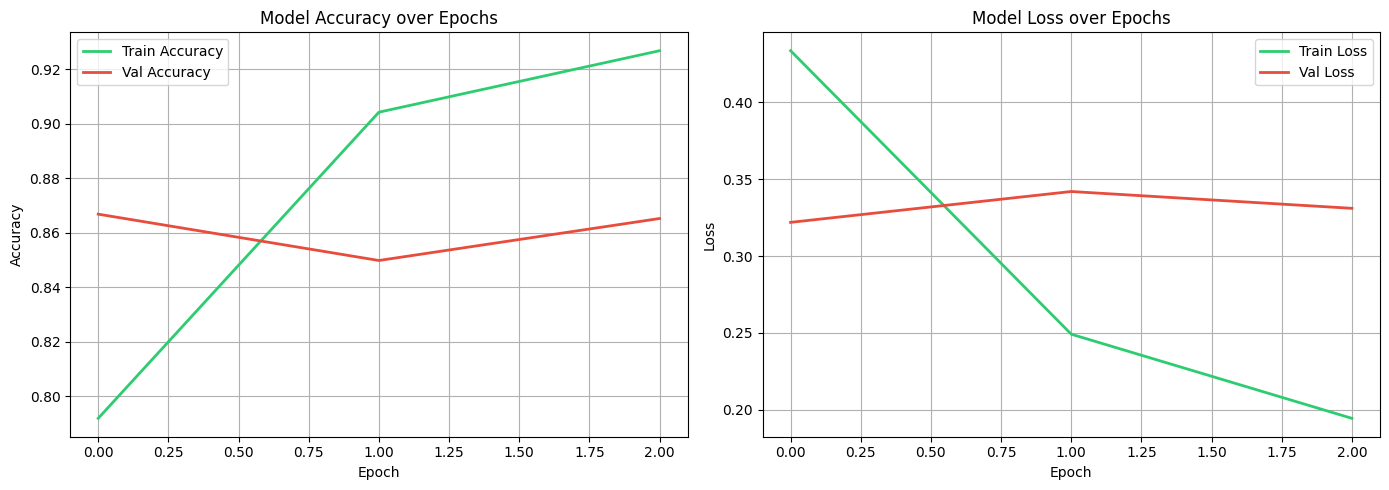

✅ Training history saved as training_history.png


In [8]:
# ================================================================
# STEP 6: VISUALIZE TRAINING HISTORY
# Plotting accuracy and loss helps us visually confirm
# how well the model learned and whether overfitting occurred.
# Green = Training, Red = Validation
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy over epochs
axes[0].plot(history.history['accuracy'],
             label='Train Accuracy', color='#2ecc71', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Val Accuracy', color='#e74c3c', linewidth=2)
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Loss over epochs
axes[1].plot(history.history['loss'],
             label='Train Loss', color='#2ecc71', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Val Loss', color='#e74c3c', linewidth=2)
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training history saved as training_history.png')

782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.8625 - loss: 0.3223

✅ Test Accuracy : 0.8625 (86.25%)
✅ Test Loss     : 0.3223

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.90      0.82      0.86     12500
    Positive       0.83      0.91      0.87     12500

    accuracy                           0.86     25000
   macro avg       0.87      0.86      0.86     25000
weighted avg       0.87      0.86      0.86     25000



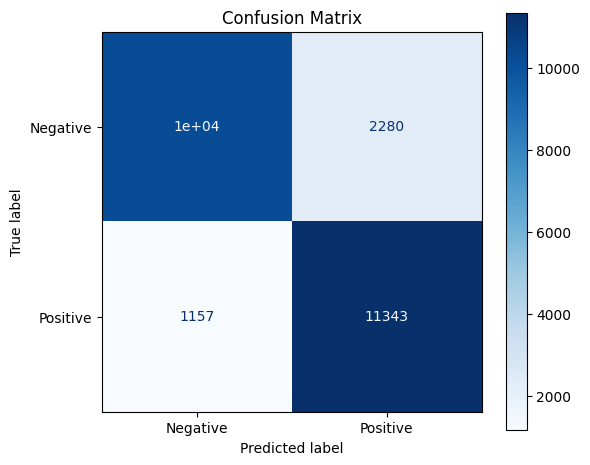

✅ Confusion matrix saved as confusion_matrix.png


In [9]:
# ================================================================
# STEP 7: EVALUATE ON TEST DATA
# Test on completely unseen data to get true real world
# performance. We also add confusion matrix and classification
# report for a more complete picture of model performance.
# ================================================================

# Basic accuracy and loss
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=1)
print(f'\n✅ Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print(f'✅ Test Loss     : {test_loss:.4f}')

# Get predicted labels (convert probabilities to 0 or 1)
y_pred_probs  = model.predict(X_test_pad, verbose=0)
y_pred_labels = (y_pred_probs > 0.5).astype(int).flatten()

# Classification report: precision, recall, F1-score per class
# Precision = of all predicted positive, how many were actually positive
# Recall    = of all actual positive, how many did we catch
# F1-Score  = balance between precision and recall
print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred_labels,
      target_names=['Negative', 'Positive']))

# Confusion matrix visualization
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_labels,
    display_labels=['Negative', 'Positive'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved as confusion_matrix.png')

In [10]:
# ================================================================
# STEP 8: PREDICT ON CUSTOM REVIEWS
# Improved preprocessing using regex to clean punctuation
# before encoding - makes tokenization more consistent
# with how the IMDB dataset was originally processed.
# Score closer to 1.0 = more positive
# Score closer to 0.0 = more negative
# ================================================================

def preprocess_review(review):
    # Lowercase the text
    review = review.lower()
    # Remove punctuation and special characters using regex
    # This matches the original IMDB tokenization more closely
    review = re.sub(r'[^a-z0-9\s]', '', review)
    # Remove extra whitespace
    review = re.sub(r'\s+', ' ', review).strip()
    return review

def predict_sentiment(review):
    # Clean and preprocess the review text
    cleaned  = preprocess_review(review)
    words    = cleaned.split()
    encoded  = [word_index.get(w, 2) + 3 for w in words]

    # Pad to same length as training data
    padded    = pad_sequences([encoded], maxlen=MAX_LEN, padding='pre')

    # Predict sentiment
    score     = model.predict(padded, verbose=0)[0][0]
    sentiment = 'Positive 😊' if score > 0.5 else 'Negative 😞'

    print(f'Review    : {review}')
    print(f'Cleaned   : {cleaned}')
    print(f'Score     : {score:.4f}')
    print(f'Sentiment : {sentiment}')
    print('-' * 60)

# Test with sample reviews
predict_sentiment('This movie was absolutely fantastic and I loved every moment of it!')
predict_sentiment('This was the worst movie I have ever seen, complete waste of time.')
predict_sentiment('The acting was okay but the story was very boring and too long.')

Review    : This movie was absolutely fantastic and I loved every moment of it!
Cleaned   : this movie was absolutely fantastic and i loved every moment of it
Score     : 0.8611
Sentiment : Positive 😊
------------------------------------------------------------
Review    : This was the worst movie I have ever seen, complete waste of time.
Cleaned   : this was the worst movie i have ever seen complete waste of time
Score     : 0.0462
Sentiment : Negative 😞
------------------------------------------------------------
Review    : The acting was okay but the story was very boring and too long.
Cleaned   : the acting was okay but the story was very boring and too long
Score     : 0.2976
Sentiment : Negative 😞
------------------------------------------------------------


In [11]:
# ================================================================
# STEP 9: SAVE THE MODEL
# Save final trained model for future use without retraining.
# Note: best_model.keras was already saved by ModelCheckpoint
# during training - this saves the final state as well.
# ================================================================

model.save('sentiment_model.keras')
print('✅ Final model saved as sentiment_model.keras')
print('✅ Best model already saved as best_model.keras (by ModelCheckpoint)')

✅ Final model saved as sentiment_model.keras
✅ Best model already saved as best_model.keras (by ModelCheckpoint)


In [12]:
# ================================================================
# STEP 10: FINAL SUMMARY
# Values printed dynamically from actual results
# so they always stay accurate even if model is retrained
# ================================================================

best_epoch = np.argmin(history.history['val_loss']) + 1

print('=' * 55)
print('      TASK 2 - DEEP LEARNING - FINAL SUMMARY')
print('=' * 55)
print(f'  Dataset          : IMDB Movie Reviews')
print(f'  Total samples    : 50,000 (25k train, 25k test)')
print(f'  Task             : Sentiment Analysis (NLP)')
print(f'  Model            : LSTM Neural Network')
print(f'  Vocabulary size  : {NUM_WORDS:,} words')
print(f'  Max review len   : {MAX_LEN} words')
print(f'  Best Epoch       : {best_epoch}')
print(f'  Test Accuracy    : {test_accuracy*100:.2f}%')
print(f'  Test Loss        : {test_loss:.4f}')
print('=' * 55)
print('  Files saved:')
print('    - sentiment_model.keras')
print('    - best_model.keras')
print('    - training_history.png')
print('    - confusion_matrix.png')
print('    - eda_plots.png')
print('=' * 55)
print('  Model executed successfully.')
print('  Sentiment Analysis model is ready! ✅')
print('=' * 55)

      TASK 2 - DEEP LEARNING - FINAL SUMMARY
  Dataset          : IMDB Movie Reviews
  Total samples    : 50,000 (25k train, 25k test)
  Task             : Sentiment Analysis (NLP)
  Model            : LSTM Neural Network
  Vocabulary size  : 10,000 words
  Max review len   : 200 words
  Best Epoch       : 1
  Test Accuracy    : 86.25%
  Test Loss        : 0.3223
  Files saved:
    - sentiment_model.keras
    - best_model.keras
    - training_history.png
    - confusion_matrix.png
    - eda_plots.png
  Model executed successfully.
  Sentiment Analysis model is ready! ✅
